# AutoValuator - Auction Price Predictor
 - Goal: Build a model based on auction data to predict auctions sale price, then power a Streamlit app
- Pipeline: Data Collection --> Data Cleaning --> Feature Engineering --> EDA --> Model Training -->  Save

In [2]:
#==================================
# AutoValuator
#==================================

In [3]:
#==================================
# 1. Imports//Setup
#==================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 30)
print('import/setup donde')

import/setup donde


In [4]:
#==================================
# 2. Load/Inspect data
#==================================

df_raw = pd.read_csv('data/cars_bids_final_3000.csv')
print(f'Shape: {df_raw.shape}')
df_raw.head(3)

Shape: (3000, 21)


,url,title,auction_date,make,model,mileage,vin,title_status,location,seller,engine,drivetrain,transmission,body_style,exterior_color,interior_color,seller_type,auction_ended,bids,comments,Unnamed: 20
0,https://carsandbids.com/auctions/rEQObdAO/2000...,2000 Toyota MR2 Spyder,"Ended October 31st, 2025 at 2:16 AM",Toyota,MR2 Spyder,"36,400",JTDFR3204Y0009875,Clean (MI),"Grand Rapids, MI 49508",Follow\nbradybronson,1.8L I4,Rear-wheel drive,Manual (5-Speed),Convertible,Liquid Silver Metallic,Black,Private Party,Sold for 10200,20.0,51.0,NaN
1,https://carsandbids.com/auctions/Kd1PN5pQ/2004...,2004 BMW M3 Coupe,"Ended October 25th, 2025 at 2:38 AM",BMW,E46 M3,"52,100",WBSBL93414PN58013,Clean (FL),"Hollywood, FL 33021",Follow\nSilberGrau,3.2L I6,Rear-wheel drive,Manual (6-Speed),Coupe,Silver Gray Metallic,Black,Private Party,Sold for 36900,17.0,24.0,NaN
2,https://carsandbids.com/auctions/3OWAz7ay/2015...,2015 Mercedes-AMG C63 S Sedan,"Ended November 1st, 2025 at 4:04 AM",Mercedes-Benz,C-Class AMG,"105,900",55SWF8HB8FU071551,Clean (PA),"Pittsburgh, PA 15203",Follow\ncf_guna,4.0L Turbocharged V8,Rear-wheel drive,Automatic (7-Speed),Sedan,Black,Black,Private Party,Bid to 20500,38.0,20.0,NaN


In [5]:
print('=== Column types ===')
print(df_raw.dtypes)
print('\n=== Null counts ===')
print(df_raw.isnull().sum())
print('\n=== Auction ended samples ===')
print(df_raw['auction_ended'].value_counts().head(10))

=== Column types ===
url                object
title              object
auction_date       object
make               object
model              object
mileage            object
vin                object
title_status       object
location           object
seller             object
engine             object
drivetrain         object
transmission       object
body_style         object
exterior_color     object
interior_color     object
seller_type        object
auction_ended      object
bids              float64
comments          float64
Unnamed: 20       float64
dtype: object

=== Null counts ===
url                  0
title                4
auction_date         4
make                 7
model                7
mileage              7
vin                  8
title_status         7
location             7
seller               7
engine               7
drivetrain           7
transmission         7
body_style           7
exterior_color       7
interior_color       7
seller_type          7
auction

In [6]:
#==================================
# 3. Data cleaning
#==================================

df = df_raw.copy()

# 3a. Parse sale price from auction ended (sold for != bid to)
def parse_price(val):
    if pd.isna(val):
        return None, None
    val = str(val)
    m = re.search(r'(\d[\d,]+)', val)
    price = int(m.group(1).replace(',', '')) if m else None
    status = 'sold' if val.startswith('Sold for') else 'not_sold'
    return price, status

df[['sale_price', 'sold_status']] = df['auction_ended'].apply(
    lambda x: pd.Series(parse_price(x))
)

print('Sold:', (df['sold_status'] == 'sold').sum())
print('Not sold:', (df['sold_status'] == 'not_sold').sum())
df[['auction_ended', 'sale_price', 'sold_status']].head(5)

Sold: 1888
Not sold: 1108


,auction_ended,sale_price,sold_status
0,Sold for 10200,10200.0,sold
1,Sold for 36900,36900.0,sold
2,Bid to 20500,20500.0,not_sold
3,Sold for 2900,2900.0,sold
4,Bid to 18250,18250.0,not_sold


In [7]:
# 3b. Extract year from title
df['year'] = df['title'].str.extract(r'(\d{4})').astype(float)

# 3c. Clean mileage
df['mileage_clean'] = (
    df['mileage'].astype(str)
    .str.replace(',', '', regex=False)
    .str.extract(r'(\d+)')
    .astype(float)
)

# 3d. Clean seller_type
df['seller_type_clean'] = df['seller_type'].fillna('').astype(str).apply(
    lambda x: 'Dealer' if 'Dealer' in x else ('Private Party' if 'Private Party' in x else 'Unknown')
)

# 3e. Simplify transmission
df['transmission_clean'] = df['transmission'].fillna('').astype(str).apply(
    lambda x: 'Manual' if 'Manual' in x else ('Automatic' if 'Automatic' in x else 'Other')
)

# f. Simplify drivetrain
df['drivetrain_clean'] = df['drivetrain'].fillna('').astype(str).apply(
    lambda x: 'RWD' if 'Rear' in x else ('4WD/AWD' if '4WD' in x or 'AWD' in x else ('FWD' if 'Front' in x else 'Other'))
)

print('Year range:', df['year'].min(), '-', df['year'].max())
print('Mileage range:', df['mileage_clean'].min(), '-', df['mileage_clean'].max())
df[['year', 'mileage_clean', 'seller_type_clean', 'transmission_clean', 'drivetrain_clean']].head(5)

Year range: 1925.0 - 2026.0
Mileage range: 0.0 - 441900.0


,year,mileage_clean,seller_type_clean,transmission_clean,drivetrain_clean
0,2000.0,36400.0,Private Party,Manual,RWD
1,2004.0,52100.0,Private Party,Manual,RWD
2,2015.0,105900.0,Private Party,Automatic,RWD
3,2014.0,45000.0,Private Party,Automatic,RWD
4,2006.0,50200.0,Private Party,Manual,4WD/AWD


In [8]:
#==================================
# 4. Feature engineering
#==================================

CURRENT_YEAR = 2026

df['car_age'] = CURRENT_YEAR - df['year']
df['mileage_per_year'] = df['mileage_clean'] / df['car_age'].replace(0,1)
df['is_high_mileage'] = (df['mileage_clean'] > 100000).astype(int)
df['is_private_seller'] = (df['seller_type_clean'] == 'Private Party').astype(int)
df['is_manual'] = (df['transmission_clean'] == 'Manual').astype(int)
df['is_rwd'] = (df['drivetrain_clean'] == 'RWD').astype(int)


# Engagement signs
df['bids_clean'] = pd.to_numeric(df['bids'], errors='coerce').fillna(0)
df['comments_clean'] = pd.to_numeric(df['comments'], errors='coerce').fillna(0)

print('New features added:')
df[['car_age', 'mileage_per_year', 'is_high_mileage', 'bids_clean']].describe()


New features added:


,car_age,mileage_per_year,is_high_mileage,bids_clean
count,2987.000000,2977.000000,3000.000000,3000.000000
mean,17.920656,4999.423445,0.240000,30.844333
std,12.476639,3666.679310,0.427154,14.468974
min,0.000000,0.000000,0.000000,0.000000
25%,9.000000,2200.000000,0.000000,20.000000
50%,15.000000,4280.000000,0.000000,29.000000
75%,24.000000,7037.500000,0.000000,40.000000
max,101.000000,24316.666667,1.000000,96.000000


In [9]:
#==================================
# 5. Xploratory data analysis (EDA)
#==================================

# Work only with SOLD cars for price analysis
df_sold = df[df['sold_status'] == 'sold'].copy()
df_sold = df_sold.dropna(subset=['sale_price', 'year', 'mileage_clean'])
# Remove obvious outliers (price < $1k or > $1M)
df_sold = df_sold[(df_sold['sale_price'] > 1000) & (df_sold['sale_price'] < 1_000_000)]
print(f'Sold + clean records: {len(df_sold)}')

Sold + clean records: 1874


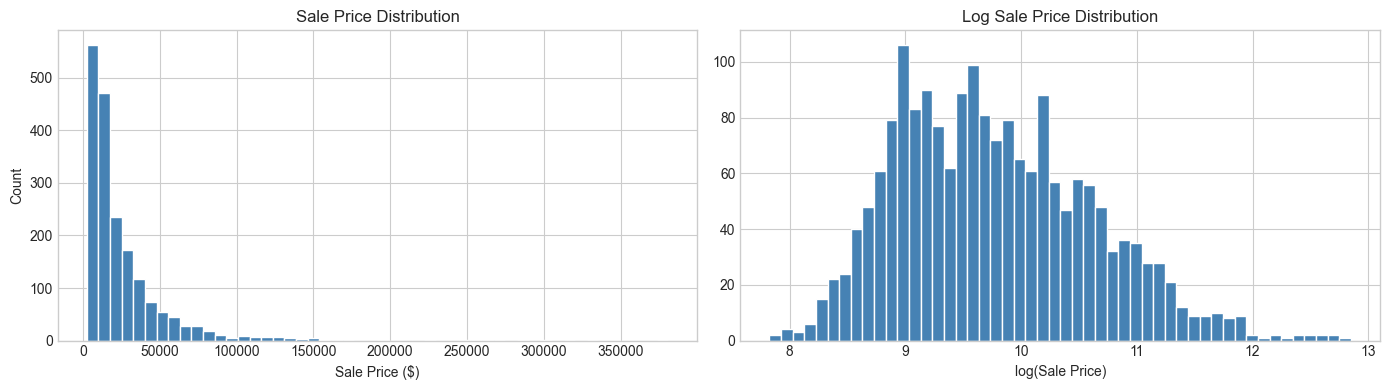

In [10]:
# 5a. Sale price distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_sold['sale_price'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Sale Price Distribution')
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(df_sold['sale_price']), bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Log Sale Price Distribution')
axes[1].set_xlabel('log(Sale Price)')

plt.tight_layout()
plt.savefig('images/plot_price_dist.png', dpi=120, bbox_inches='tight')
plt.show()

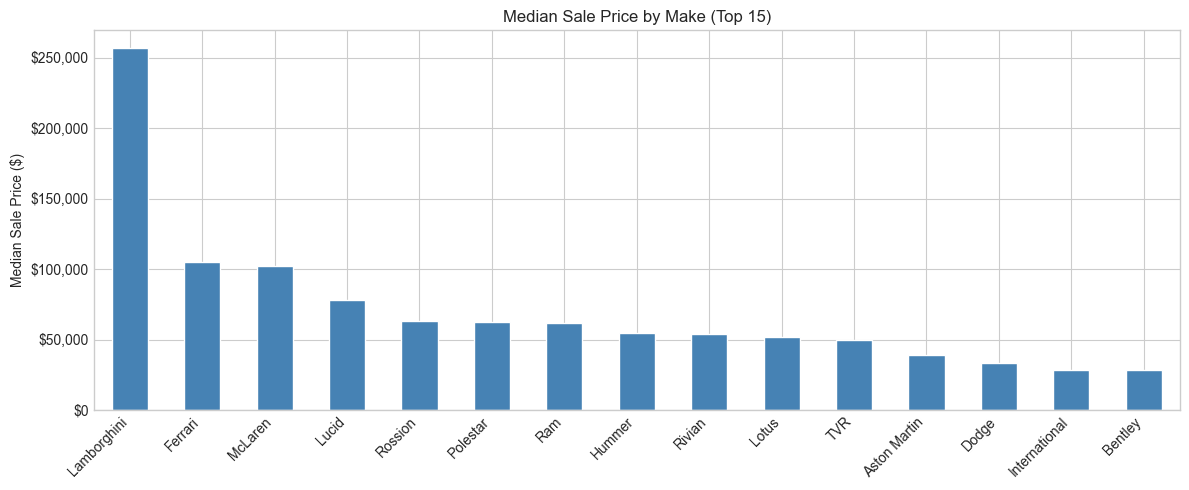

In [11]:
# 5b. Average price by make (top 15)
top_makes = df_sold.groupby('make')['sale_price'].median().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 5))
top_makes.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Median Sale Price by Make (Top 15)')
ax.set_xlabel('')
ax.set_ylabel('Median Sale Price ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('images/plot_price_by_make.png', dpi=120, bbox_inches='tight')
plt.show()

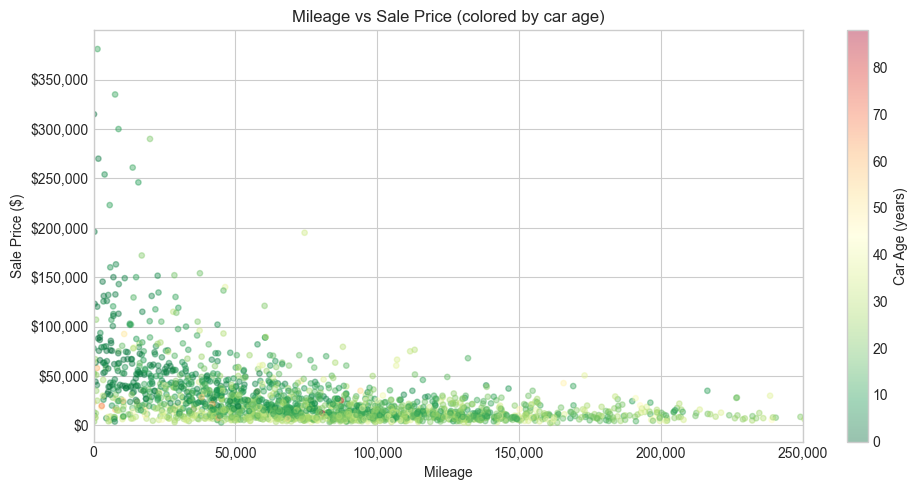

In [12]:
# 5c. Mileage vs Sale Price
fig, ax = plt.subplots(figsize=(10, 5))
sc = ax.scatter(
    df_sold['mileage_clean'], df_sold['sale_price'],
    c=df_sold['car_age'], cmap='RdYlGn_r', alpha=0.4, s=15
)
plt.colorbar(sc, ax=ax, label='Car Age (years)')
ax.set_title('Mileage vs Sale Price (colored by car age)')
ax.set_xlabel('Mileage')
ax.set_ylabel('Sale Price ($)')
ax.set_xlim(0, 250_000)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('images/plot_mileage_vs_price.png', dpi=120, bbox_inches='tight')
plt.show()

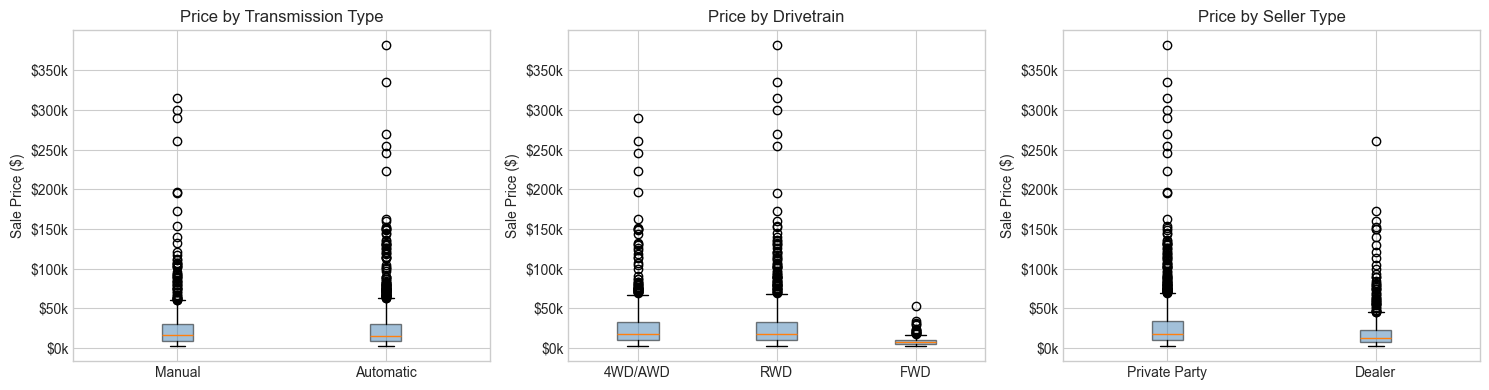

In [13]:
#  5d. Transmission, Drivetrain & Seller Type impact
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, title in zip(axes,
    ['transmission_clean', 'drivetrain_clean', 'seller_type_clean'],
    ['Transmission Type', 'Drivetrain', 'Seller Type']):
    order = df_sold.groupby(col)['sale_price'].median().sort_values(ascending=False).index
    data = [df_sold[df_sold[col] == g]['sale_price'].values for g in order]
    ax.boxplot(data, labels=order, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.5))
    ax.set_title(f'Price by {title}')
    ax.set_ylabel('Sale Price ($)')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

plt.tight_layout()
plt.savefig('images/plot_categorical_impact.png', dpi=120, bbox_inches='tight')
plt.show()

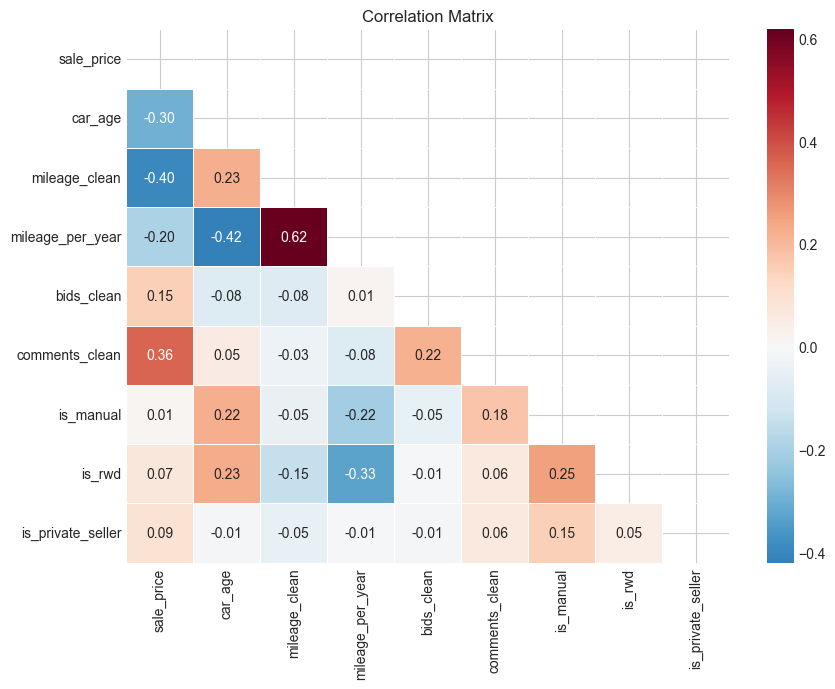

In [14]:
#  5e. Correlation heatmap (numeric features)
num_cols = ['sale_price', 'car_age', 'mileage_clean', 'mileage_per_year',
            'bids_clean', 'comments_clean', 'is_manual', 'is_rwd', 'is_private_seller']
corr = df_sold[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.savefig('images/plot_correlation.png', dpi=120, bbox_inches='tight')
plt.show()

In [15]:
#==================================
# 6. Model building
#==================================

# 6a. Feature selection
# FIX 1: added 'model' — biggest single signal (911 vs Boxster vs Macan)
# FIX 3: removed 'car_age' and 'mileage_per_year' — both derived from 'year'
#         so they were redundant and added noise
CATEGORICAL_FEATURES = ['make', 'model', 'body_style', 'transmission_clean', 'drivetrain_clean', 'seller_type_clean']
NUMERIC_FEATURES     = ['year', 'mileage_clean',
                         'bids_clean', 'is_manual', 'is_rwd', 'is_private_seller',
                         'is_high_mileage']
TARGET = 'sale_price'

FEATURES = CATEGORICAL_FEATURES + NUMERIC_FEATURES

model_df = df_sold[FEATURES + [TARGET]].dropna()
print(f'Training records: {len(model_df)}')
model_df.head(3)

Training records: 1874


,make,model,body_style,transmission_clean,drivetrain_clean,seller_type_clean,year,mileage_clean,bids_clean,is_manual,is_rwd,is_private_seller,is_high_mileage,sale_price
0,Toyota,MR2 Spyder,Convertible,Manual,RWD,Private Party,2000.0,36400.0,20.0,1,1,1,0,10200.0
1,BMW,E46 M3,Coupe,Manual,RWD,Private Party,2004.0,52100.0,17.0,1,1,1,0,36900.0
3,Smart,Fortwo,Hatchback,Automatic,RWD,Private Party,2014.0,45000.0,18.0,0,1,1,0,2900.0


In [16]:
# 6b. Encode categoricals

# OrdinalEncoder works well with XGBoost — maps each category to an integer
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
model_df_enc = model_df.copy()
model_df_enc[CATEGORICAL_FEATURES] = enc.fit_transform(model_df[CATEGORICAL_FEATURES])

X = model_df_enc[FEATURES].values

# FIX 2: train on log(price) — price is right-skewed, log makes it symmetric
# XGBoost predicts more accurately on a symmetric target
y = np.log1p(model_df_enc[TARGET].values)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')
print(f'Target is log-transformed. Sample y values: {y[:5].round(3)}')

Train: 1499 | Test: 375
Target is log-transformed. Sample y values: [ 9.23  10.516  7.973 10.106  9.632]


In [17]:
#  6c. Train XGBoost
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
print('Model trained')

Model trained


In [18]:
#==================================
# 7. Model evaluation
#==================================

# FIX 2: model predicts log(price) — reverse with expm1 to get dollar predictions
y_pred_log = model.predict(X_test)
y_pred     = np.expm1(y_pred_log)       # back to dollars
y_test_actual = np.expm1(y_test)        # back to dollars

mae  = mean_absolute_error(y_test_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
r2   = r2_score(y_test_actual, y_pred)

print(f'MAE  : ${mae:,.0f}')
print(f'RMSE : ${rmse:,.0f}')
print(f'R²   : {r2:.3f}')


MAE  : $7,656
RMSE : $16,315
R²   : 0.752


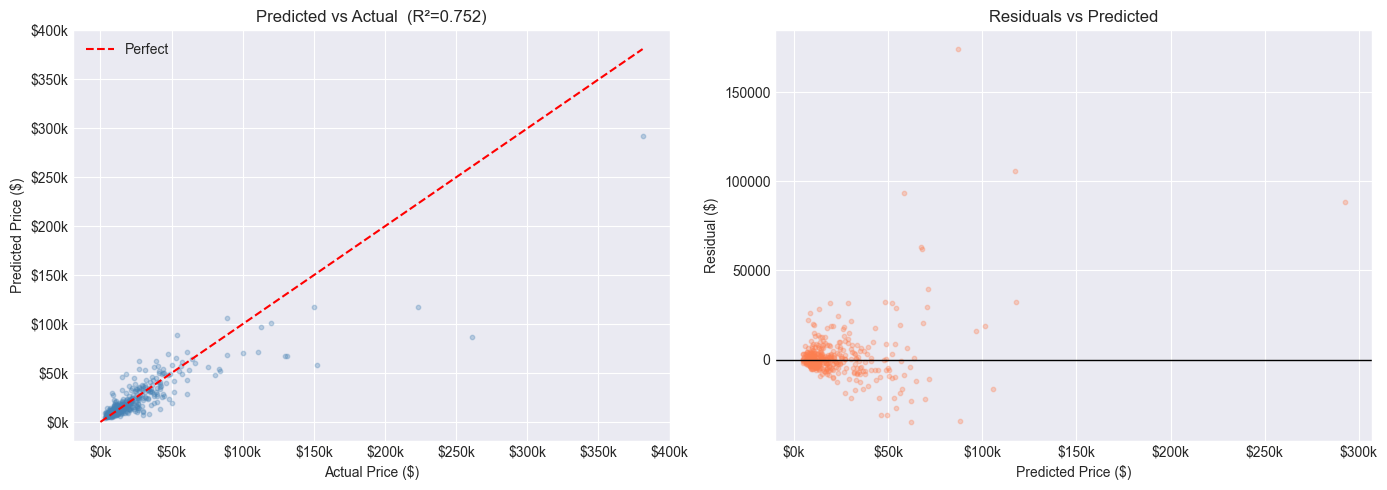

In [19]:
# 7a. Predicted vs Actual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Use dollar-scale values (expm1 already applied above)
axes[0].scatter(y_test_actual, y_pred, alpha=0.3, s=10, color='steelblue')
max_val = max(y_test_actual.max(), y_pred.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', lw=1.5, label='Perfect')
axes[0].set_title(f'Predicted vs Actual  (R²={r2:.3f})')
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].legend()

residuals = y_test_actual - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.3, s=10, color='coral')
axes[1].axhline(0, color='black', lw=1)
axes[1].set_title('Residuals vs Predicted')
axes[1].set_xlabel('Predicted Price ($)')
axes[1].set_ylabel('Residual ($)')

for ax in axes:
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

plt.tight_layout()
plt.savefig('images/plot_predicted_vs_actual.png', dpi=120, bbox_inches='tight')
plt.show()


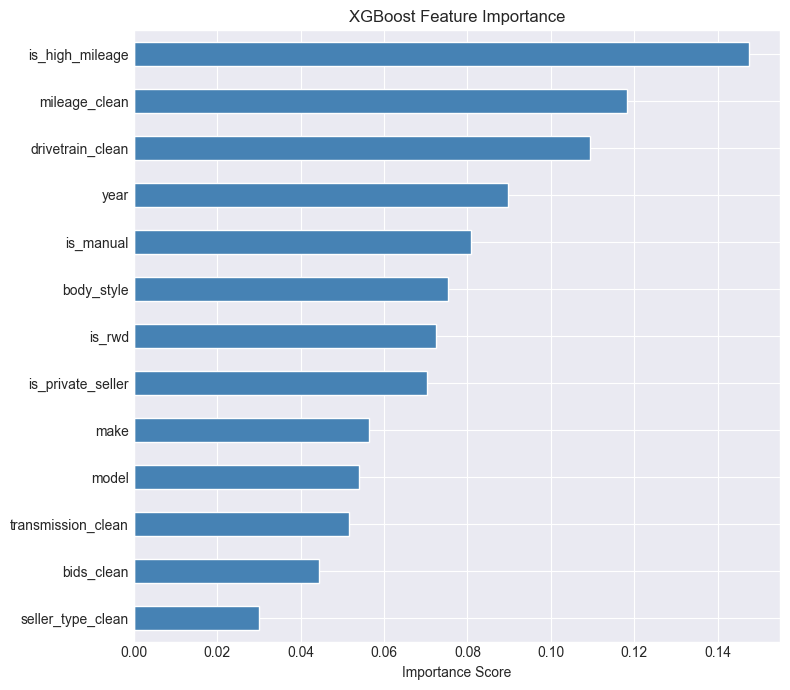

In [20]:
# 7b. Feature Importance
importance = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
importance.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('XGBoost Feature Importance')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('images/plot_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

In [21]:
#==================================
# 8. Save 4 Streamlit app
#==================================
# Save model
with open('models/model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save encoder
with open('models/encoder.pkl', 'wb') as f:
    pickle.dump(enc, f)

# Save feature metadata (needed for dropdowns in Streamlit)
feature_meta = {
    'categorical_features': CATEGORICAL_FEATURES,
    'numeric_features': NUMERIC_FEATURES,
    'all_features': FEATURES,
    'categories': {
        col: sorted(model_df[col].dropna().unique().tolist())
        for col in CATEGORICAL_FEATURES
    },
    'numeric_stats': {
        col: {'min': float(model_df[col].min()), 'max': float(model_df[col].max()),
              'mean': float(model_df[col].mean())}
        for col in NUMERIC_FEATURES
    },
    'model_metrics': {'mae': round(mae, 2), 'rmse': round(rmse, 2), 'r2': round(r2, 3)}
}
with open('feature_meta.json', 'w') as f:
    json.dump(feature_meta, f, indent=2)

# NEW — added car_age
df_sold[FEATURES + [TARGET, 'sold_status', 'title', 'auction_date', 'location', 'car_age']].to_csv(
    'data/cars_bids_clean.csv', index=False
)

print('Saved: model.pkl, encoder.pkl, feature_meta.json, cars_bids_clean.csv')

Saved: model.pkl, encoder.pkl, feature_meta.json, cars_bids_clean.csv
